# LangGraph-Based Agent Workflow

1. Learning objectives:
This note will give:
- The difference between an AI workflow and an AI agent.
- Understanding why graph-based orchestration is useful for agentic AI.
- Defining LangGraph state, nodes, edges, reducers, and conditional routing.
- Building an agent that repeatedly calls tools until it reaches an answer.
- Adding persistence, conversational memory, retries, and human approval.
- Understanding subgraphs, streaming, fault recovery, and production design.
- Deciding when to use LangGraph instead of a simple LangChain agent.


# 2. What is LangGraph?

LangGraph is a low-level orchestration framework for building stateful, long-running, controllable agent systems.

It represents an application as a graph containing three primary components.

* State: The shared data of the application.
* Nodes: Functions that perform work.
* Edges: Transactions that decide which node executes next.

A node might call an LLM, execute a tool, query a database, validate output, request human approval or perform ordinary Python logic. Edges connect these operations and can create sequences, branches, parallel paths, and loops.

The central idea is:
    `Nodes perform work. Edges determine what happens next. State carries information through the workflow.`
LangGraph is not itself an LLM. It sits around one or more LLMs and controls how they interact with tools,memory, people, APIs, databases, and other agents.



# 3. Workflow versus agent:

Although the terms are frequently used together, they are not identical.

### 3.1 Workflow:
A workflow follows paths primarily designed by the developer.

Example:

`
Receive question
 ↓
Retrieve documents
 ↓
Generate answer
 ↓
Verify citations
 ↓
Return result
`
The developer has already decided the order.

### 3.2 Agent:

An agent dynamically decides:
* Whether it needs a tool;
* Which tool to call.
* What arguments to provide.
* Whether the tool result is sufficient.
* Whether another tool call is necessary.
* When to stop.

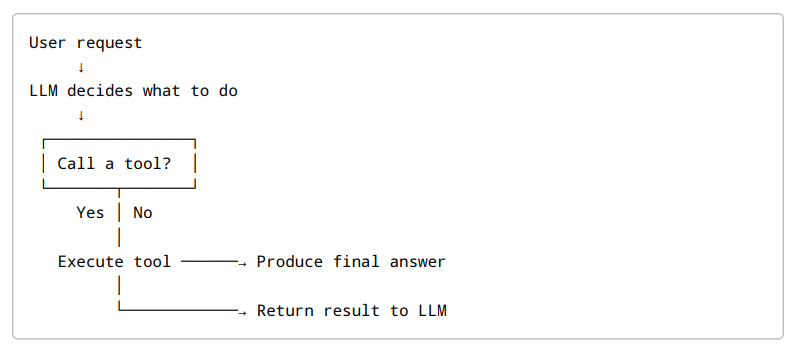

LangGraph documentation describes workflows as following predetermined code paths, while agents dynamically determine their processes and tool usage. LangGraph can combine both approaches inside one appliaction.

For example, the LLM may dynamically select tools, but a deterministic security node may always inspect the result before it is returned.



# 4. Why do we need LnagGraph?

A simple tool-calling agent often looks like this 

```Python
while True:
    response = model(messages)
    if response.has_tool_calls:
        results = execute_tools(response.tool_calls)
        messages.extend(results)

    else:
        return response
```
This works for small demonstrations. Production systems, however, usually need more control:

* multiple branches;
* persistent conversations;
* retries after API failure;
* human approval;
* resumable execution;
* multiple agents;
* tool restrictions;
* output validation;
* streaming;
* observability;
* recovery from crashes;
* limits on looping;
* state inspection;

As an agent grows, a single `while` loop becomes difficult to understand and maintain. LangGraph makes the control flow explicit.

Instead of hiding the process inside one function, we can represent it as :

```
START
 ↓
classify_request
 ↓
plan_task
 ↓
agent
 ├── tool required ──→ tools ──→ agent
 ├── unsafe action ──→ human approval
 └── answer ready ───→ validate ──→ END
 ```
This explicit structure improves testability, debugging, control, and failure recovery.



# 5. LangGraph's core components:

5.1 State:

State represents the current snapshot of the application.

It can contain:

```Python
{
    "messages":[....],
    "user_id":"user_123",
    "task_type":"research",
    "documents":[.....],
    "tool_attempts":2,
    "approved":False,
    "final_answer":"....."
}
```


Every node receives the current state and returns one or more updates.

LangGraph commonly defines state with:
* TypeDict.
* dataclass.
* Pydantic `BaseModel`

`TypeDict` is usually appropriate when you need lightweight type hints. Pydantic is useful when more expensive runtime validation is required, although it has additional overhead.

Example:

```Python
from typing_extensions import TypeDict

class AgentState(TypeDict):
    user_query: str
    task_type: str
    answer: str
```
A node does not normally need to return the entire state;

```
def classify_task(state: AgentState):
    return {"task_type": "research"}
```
LangGraph merges this update into the existing stae.


# 5.2 Reducers
A reducer tells LangGraph how a state field should be updated.
Consider this state:

```
{
    "messages":["Message 1","Message 2"]
}
`
A new node returns:
`
{
    "messages":["Message 3"]
}
```
Should LangGraph replace the old list or append to it?
Without a reducer, the default behavior is usually replacement.

With an append reducer:

```
from typing import Annotated
import operator
from typing_extensions import TypeDict

class State(TypeDict):
    messages: Annotated[list, operator.add]
```

The new result becomes:

```
{
    "messages":[
        "Message 1",
        "Message 2",
        "Message 3"
    ]
}
```
For chat messages, LangGraph provides message-oriented state helpers such as `MessagesState` an `add_messages`.

Example:

```
from langgraph.graph import MessagesState

class AgentState(MessagesState):
    user_id: str
    task_status: str
```

`MessageState` already defines a suitable message reducer.


# Important rule:
Use the correct semantics for each field:

```Python
class State(TypeDict):
    messages: Annotated[list, add_messages] # Append or merge
    attempts: int     # Replace with latest value.
    retrieved_docs: Annotated[list, operator.add]
    final_answer: str         # Replace

```
Poor reducer design can create duplicate messages, lost data, or conflicting parallel updates.



# 5.3 Nodes
A node is normally a Python function.

```
def normalize_input(state: AgentState):
    query = state["user_query"].strip()

    return {
        "user_query":query
    }
```

A node can be synchronous:

`
def call_model(state):
    ....
`
Or a Node can be asynchronous:

`
async def call_model(state):
    ....
`

A node can contain:
* deterministic Python;
* an LLM call;
* database operations;
* API requests;
* retrieval;
* validation;
* moderation;
* tool execution;
* human interruption.

Nodes should normally have one clear responsibility.

Good  node names:

```
classify_request
retrieve_documents
grade_documents
generate_answer
validate_answer
request_approval
execute_payment
```

Less useful node names:

```
process_everything
main_logic
do_task
agent_stuff
```






# 5.4 Edges 
Edges define transitions

Normal edge
`builder.add_edge("retrieve","generate")`

This means:
`retrieve -> generate`

Entry edge:
`builder.add_edge(START, "classify")`

Final edge:
`builder.add_edge("generate",END)`


Conditional edge:
`A conditional edge chooses a destination based on state.`

```Python
def route_request(state):
    if state["task_type"]=="research":
        return "retrieve"
    return "direct_answer"
```

Register it:

```Python
builder.add_conditional_edges(
    "calssfify",
    route_request,
    {
        "retrieve":"retrieve",
        "direct_answer":"direct_answer",
    },
)
```

Graph:
```
                 ┌──→ retrieve
classify ────────┤
                 └──→ direct_answer
```
Conditional edges are essential for agent loops, validation, escalation, retries, and routing.


# 5.5 START and END

`START` and `END` are special graph markers.

`from langgraph.graph import START, END`

`START` indicates where graph execution begins:

`builder.add_edge(START,"agent")`

`END` indicates termination:

`builder.add_edge("finalize", END)`

They are not normal business-logic nodes.



# 6. Understanding the agent loop:

A standard tool-calling agent uses the following loop:

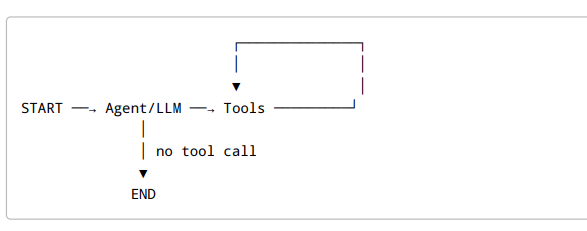

The steps are:

1. The user sends a messag.
2. The LLM examines the message.
3. The LLM either:

4. Produces a final answer; or
5. Generates a structured tool call.#
6. LangGraph executes the requested tool.
7. The tool result is added to the message history.
8. The LLM is called again.
9. The cycle continues until there are no more tool calls.

This is the foundation of a ReAct-style tool-using agent.

The reasoning and acting cycle can be understood conceptually as:

`
Observe -> Decide -> Act -> Observe result -> Decide again
`
In application state, store operational decisions, tool requests, results, and status. Do not rely on exposing or storing hidden model reasoning.


# 7. Complete LangGraph tool-calling workflow:

The following project creates an assistant that can:

* Answer normally.
* Look up products from a local catalogue;
* Calcualate order costs.
* Call multiple tools;
* Loop until it has enough information;
* Preserve conversation state.

# 7.1 Installation
`pip install -U langgraph langchain langchain-anthropic`


LangGraph v1 retains the stable state, node, edge, persistence, streaming, and human-in-the-loop primitives. The older LangGrpah-specific `create_react_agent` prebuilt is deprecated in favour of newer high-level LangChain agents, but raw  `StateGraph` reamins appropriate when you need custom orchestration.



# 7.3 Initialize the model

```Python 
from langchain.chat_models import init_chat_nodel

model = init_chat_model(
    "anthropic:claude-sonnet-4-6",
    temperature=0,
)
tools = [
    search_product,
    calculate_order_cost,
]
model_with_tools = model.bind_tools(tools)

```

`bind_tools()` sends the tools' schemas to the model. The model does not directly execute the Python functions. It produces structured instructions requesting tool execution.

LangGraph then executes the selected function through a tool node.



# 7.4 Define state:

```Python 
from langgraph.graph import MessageState

class AgentState(MessagesState):
    model_calls: int

```

The state contains:
`
{
    "messages":[.....],
    "model_calls":0
}
`

`messages` carries:
    * User messages.
    * Assitant messages;
    * Assitant tool-call requests;
    * Tool results;
    * Final assistant response.
`model_calls` helps us inspect how many times the model was invoked.


# 7.5 Create the agent node:

```Python
from langchain.messages import SystemMessage

SYSTEM_PROMPT = """
You are a product assistant. 
You can:
1. Look up product information.
2. Calculate estimate order costs.

Rules:
- Use search_product before claiming a catalogue price. 
- Never invent stock or price information.
- Use calculate_order_cost when the user asks for the total price.
- Clearly state that the result is an estimate.
- Do not claim that an order has been placed.
"""

def call_agent(state:AgentState)->dict:
    """Call the LLM and allow it to request tools."""
    response = model_with_tools.invoke(
        [
            SystemMessage(content=SYSTEM_PROMPT),
            *state["messages"],

        ]
    )
    return {
        "messages":[response],
        "model_calls":state.get("model_calls",0)+1,
    }
```

Notice that the node returns:
`
{
    "messages":[response]
}
`

It does not manually append to the existing messages. The message reducer handles that operation.


# 7.6 Create the tool node

```Python
from langgraph.prebuilt import ToolNode

tool_node = ToolNode(
    tools,
    handle_tool_errors =True,
)
```
`ToolNode` is a prebuilt LangGraph node for tool execution. It can exectute requested tools, support parallel calls, return tool messages, inject state where configured, and handle tool errors.

With: 
`handle_tool_errors = True`
many tool errors are converted into tool-result messages so the LLM has an opportunity to correct its arguments.
In a financial or other  high-risk application, you may prefer a custom error handler rather than exposing exception text.

# 7.7 Define routing:

```Python
from typing import Literal

def route_after_agent(
    state: AgentState,
    )-> Literal["tools","__end__"]:
    """Route to tools when the latest AI message has tool calls."""
    latest_message = state["message"][-1]

    if latest_message.tool_calls:
        return "tools"
    return "__end__"

```



The router examines the most recent AI message.
If it contains:

`tool_calls=[....]`

execution moves to the tool node.

Otherwise, the model has produced a final answer and the graph ends.

# 7.8 Build the graph

```Python
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.types import RetryPolicy

builder = StateGraph(AgentState)
builder.add_node(
    "agent",
    call_agent,
    retry_policy = RetryPolicy(max_attemts=3),
)
builder.add_node(
    "tools",
    tool_node,
)
builder.add_edge(
    START,
    "agent",
)
builder.add_conditional_edges(
    "agent",
    route_after_agent,
    {
        "tools":"tools",
        "__end__":END,
    },
)
builder.add_edge(
    "tools",
    "agent",
)
checkpointer = InMemorySaver()
graph = builder.compile(
    checkpointer = checkpointer,
)
```



```
The resulting graph is:
 tool requested
             ┌────────────────────┐
             │                    │ 
             ▼                    ▼
START ───────→ AGENT            TOOLS
             
             ▲                    ▲
             └────────────────────┘
             │
             │ no tool requested
             ▼
            END
```
The retry policy automatically retries the `agent` node when suitable transient errors occur. LangGraph supports node retry policies with configurable attempts and backoff behaviour.


# 7.9 Invoke the Graph:

```Python
from langchain.messages import HumanMessage
config ={
    "configurable":{
        "thread_id":"customer-001-conversation-001"
    }
}
result = graph.invoke(
    {
        "messages": [
            HumanMessage(
                content=(
                    "What would be the estimated total cost"
                    "of buying 3 keyborads?"
                )
            )
        ],
        "model_calls":0,
    },
    config=config,
)
print(result["messages"][-1].content)
print("Model calls:", result["model_calls"])

```

A likely execution trajectory is:

1. User asks for the cost of three keyboards.
2. Agent calls search_product("keyboard").
3. Tool returns a price of 75.
4. Agent calls calcualte_order_costs(75,3).
5. Tool returns the subtotal and estimated total.

6. Agent produces the final response.

The model selected two tools dynamically, But, LangGraph controlled the execution loop.




# 8. Understanding what happens inside the graph:

Suppose the initial state is:

```Python
{
    "messages":[
        HumanMessage(
            content="What is the total cost of three keyboards?"

        )
    ],
    "model_calls":0
}
```

# Step 1: Agent node

The agent might return:

```Python
AIMessage(
    content="",
    tool_calls=[
        {
            "name":"search_product",
            "args":{
                "product_name":"keyboard"
            }
        }
    ]
    )
```

# Step 2: Conditional edge
The router detects `tool_calls`, so it chooses:

`agent->tools`

# Step 3: Tool Node
The tool result is added:

```Python
ToolMessage(
    content='{"name":"Mechanical Keyboard","price":75.0}',
    tool_call_id ="...."
)
```
# Step 4: Return to agent:

The edge:
`builder.add_edge("tools", "agent")`
Sends control back to the model.


# Step 5: Second tool request
The model now knows the price and may request:

```
calculate_order_cost(
    unit_price=75,
    quantity=3
)
```

# Step 6: Tool executes:
The reuslt might be:

```
{
    "subtotal":225,
    "delivery_charge":5,
    "estimated_total":230
}
```
# Step 7: Final model response:

The model no longer requests a tool. It produces a normal text response.

The router chooses:

# Step 7: Final model response:

The model no longer requests a tool. It produces a normal text response.
The router chooses:

`agent -> END`

# Persistence and threads
Without persistence, an agent run exists only during one invocation.
LangGraph checkpointers save state snapshots as checkpoints. These checkpoints support;

- Conversational continuity;
- Resuming interrupted workflows;
- Human-in-the loop;
- Fault recovery;
- State inspection;
- Replying earlier execution states.

A thread ID identifies the conversation or workflow instance.

Example:

```Python
config ={
    "configurable":{
        "thread_id":"conversation-123"
    }

}
```

First message:

```Python
graph.invoke(
    {
        "messages":[
            {
                "role":"user",
                "content":"I am interested in the keyboard."
            }

        ]
    },
    config=config,
)
```

Second message with the same thread:

```Python
graph.invoke(
    {
        "messages":[
            {
                "role":"user",
                "content":"what is the cost of two of them?"
            }
        ]
    },
    config=config,
)
```

Because the same `thread_id` is used, the graph can load the earlier state.

A different ID creates a different conversation:

```Python
new_config ={
    "configurable":{
        "thread_id":"conversation-456"
    }
}
```

# Development versus production:

`InMemorySaver` is suitable for experimentation:

`from langgraph.checkpoint.memory import InMemorySaver`

However, it stores data in process memory and loses it when the process restarts.

Production applications should use persistent storage such as PostgreSQL. LangGraph documentation distinguishes checkpointers for thread-scoped state from stores usef for long-term, cross-thread information.

# 10. Short-term and long-term memory:
These concepts should not be confused.

### 10.1 Short-term memory:
Short-term memory belongs to one workflow thread.
Examples:

- Conversation messages.
- Current task plan;
- Retrieved documents;
- Pending approval;
- Intermediate tool results.

It is generally stored through a checkpointer.

```
Thread A:
User question -> tool results -> response

Thread B:
Different question -> different state.
```

#### 10.2 Long-term memory:
Long-term memory exists across different threads.
Examples:
- User preferences.
- Preferred response language;
- Previously approved facts;
- customer profile information.
LangGraph stores can persist application-defined data outside one graph thread. A common architecture uses both:

```
Checkpointer:
Current conversation and execution state

Storage:
Durable user preferences and cross-conversation facts.
```

LangGraph officially distinguishes checkpointers as short-term, thread-scoped persistence and stores as long-term, cross-thread persistence.


# 11. Human-in-the-loop workflow
Some agent actions should not be executed automatically.

Examples:
- Sending an email;
- Deleting data;
- Placing an order;
- Transferring money;
- Publishing content;
- Modifying production infrastructure;
- Submiting a visa or university application.

A human-in-the-loop workflow can pause the graph before the action.

```
Agent prepares action
 ↓
 Request approval
 ↓
 Graph pauses
 ↓
Human approves or rejects
 ↓
Graph resumes
```

LangGraph's `interrupt()` pauses graph execution, saves the state through the persistence layer, and waits for external input. The graph resumes using the same thread ID and `Command(resume=...)`.

# Approval node:

```Python
from langgraph.types import interrupt
def request_approval(state):
    decision = interrupt(
        {
            "question":"Do you approve this action?",
            "proposed_action":state["proposed_action"],

        }
    )
    return {
        "approval_decision":decision
    }
```





# Approval Node:

```Python
from langgraph.types import interrupt

def request_approval(state):
    decision = interrupt(
        {
            "question":"Do you approve this action?",
            "proposed_action":state["proposed_action"],

        }

    )
    return {
        "approval_decision":decision
    }
```

# Resume the workflow

Initial execution:

```Python
config ={
    "configurable":{
        "thread_id":"approval-thread-001"
    }
}

result = graph.invoke(
    {
        "proposed_action":"Send the generated email"
    },
    config = config,
)
```

The result indicates an interrupt:

Resume after approval:

```Python
from langgraph.types import Command
result = graph.invoke(
    Command(
        resume={
            "approved": True,
            "reviewer": "manager@example.com",
        }
    ),
    config = config,
)
```
The same thread ID must be reused.

# Important interrupt rules:

Code before an interrupt may execute again when the node resumes. Threfore:

* Avoid non-idempotent side effects before `interrupt()`;
* Do not charge a card before asking for approval.
* Do not send an email before approval;
* Do not wrap interrupts carelessly in broad exception handling;
* Use JSON-serializable interrupt payloads.

The official documentation specifically warns that side effects occuring before an interrupt should be idempotent.

# 12. Error handling and recovery:

Agents fail in more ways than ordinary deterministic functions. 
Possible failures include:

- LLM timeout.
- Malformed tool arguments;
- Unavailable API;
- Database failure;
- Empty retrieval;
- Tool authorization failure;
- Invalid structured output;
- Repeated looping.
- Unsafe request.
- Model hallucination.

A robust graph separates recoverable failures from permanent failures.

# 12.1 Retry transient failures:

```Python
from langgraph.types import RetryPolicy

builder.add_node(
    "external_api",
    call_external_api,
    retry_policy = RetryPolicy(
        max_attempts =3,
        initial_interval =1.0,
        backoff_factor = 2.0
    )
)
```
Good retry candidates:

* HTTP 429 rate limits;
* Temporary network errors;
* Service-unavailable responses;
* Model-provider timeouts.

Poor retry candidates:

* Invalid user input.
* Missing required permission;
* Incorrect database schema;
* Deterministic programming errors;

Retrying a permanent failure only increases latency and cost.

# 12.2 Tool error handling:

```Python
tool_node = ToolNode(
    tools,
    handle_tool_errors = True,
)
```
You can also define a custom handler:

```Python
def handle_tool_error(error: ValueError) -> str:
    return (
        "The tool received invalid input."
        f"Correct the arguments and try again: {error}"
    )
tool_node= ToolNode(
    tools,
    handle_tool_errors=handle_tool_error,
)
```

# 12.3 Limit loops:

An agent may repeatedly call the same tool.

Possible protections:

```Python
class AgentState(MessagesState):
    model_calls:int
    tool_calls: int
```
Router:
```Python
def route_after_agent(state):
    if state["model_calls"]>=10:
        return "fallback"
    latest_message = state["messages"][-1]

    if latest_message.tool_calls:
        return "tools"
    
    return "__end__"
```

You should define:
* Maximum model calls;
* Maximum tool calls;
* Maximum total execution time;
* Maximum cost;
* Maximum repeated identical actions;

# 13 Validation and self-correction:
An agent should not always return the first generated response.

A stonger workflow is:

```Python
Retrieve
 ↓
Generate
 ↓
Validate
 ├── Pass ──→ END
 └── Fail ──→ Regenerate
```

State:

```Python
class ValidationState(TypeDict):
    question: str
    draft: str
    validation_errors: list[str]
    revision_count: int
```
Validator:
```Python
def validate_answer(state):
    errors=[]

    if no state["draft"].strip():
        errors.append("The answer is empty.")

    if len(state["draft"])<50:
        errors.append("The answer is insufficiently detailed.")

    return {
        "validation_errors": errors
    }
```
Router:

```Python
def route_validation(state):
    if not state["validation_errors"]:
        return "finish"
    if state["revision_count"]>=2:
        return "fallback"

    return "revise"
```

This is more reliable than asking one model call to "do everything perfectly."


# 14. Common LangGraph workflow patterns:

## 14.1 Prompt chaining:

```
Generate outline
 ↓
Write draft
 ↓
Edit draft
 ↓
Format output
```
Use when a task can be decomposed into predictable stages.

## 14.2 Routing:

```
                 ┌──→ Technical agent
User request ────┼──→ Billing agent
                 └──→ General agent
```
Use when different request categories require different instructions or tools.

## 14.3 Parallelization:

```Markdown
                   ┌──→ Search source A ──┐
Question ──────────┼──→ Search source B ──┼──→  Combine
                   └──→ Search source C ─
```
Use when independent tasks can run simultaneously.

## 14.4 Orchestrator-worker:

```Python

                 ┌──→ Worker 1
Orchestrator ────┼──→ Worker 2 ──→ Synthesizer
                 └──→ Worker 3
```
The orchestrator breaks a task into subtasks. Workers execute them. A final node combines the results.

Useful for:

* Deep reserach;
* Multi-document analysis;
* Codebase analysis;
* Generating multiple report sections.

## 14.5 Evaluator-optimizer

```Python
Generate
 ↓
Evaluate
 ├── acceptable ──→ END
 └── weak ────────→ Improve ──→ Evaluate
```
Use when output quality can be judged against a rubric.

## 14.6 Agent-tool loop:

```Python
Agent
 ├── tool call ──→ Tool ──→ Agent
 └── answer ─────→ END
```
Use when the model must dynamically choose tools.

LangGraph's official workflow documentation includes prompt chaining, parallelization, routing, orchestrator-worker, evaluator-optimizer, and agent patterns.

# 15. Subgraphs and multi-agent systems:
A subgraph is graph used as a node inside another graph.

Example:

```
Supervisor graph
 │
 ├── Research subgraph
 ├── Coding subgraph
 └── Review subgraph
```
A parent graph might delegate research to a specialized subgraph:

```Python
research_graph = research_builder.compile()
parent_builder.add_node(
"research_agent",
research_graph,
)
```
Subgraphs are useful for:

* Multi-agent systems;
* Reusing workflows;
* Isolating state;
* Simplifying large graph architectures.

If the parent and child share compatible state keys, the compiled subgraph can be added directly as a node. If their state schemas differ, a wrapper node should transform teh parent state into subgraph input and map the subgraph output back to parent state.

Example architecture:

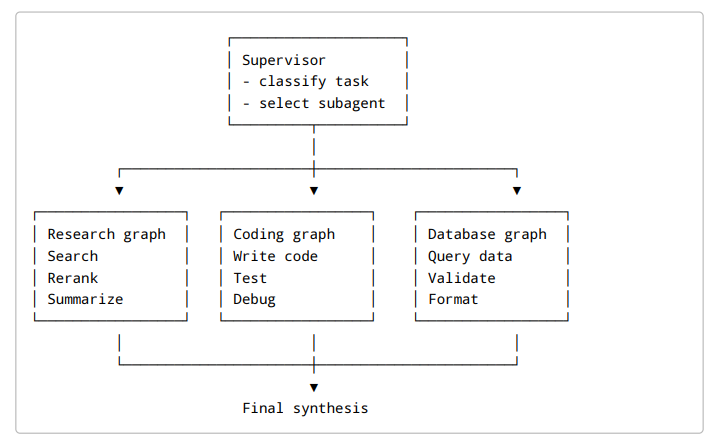

Do not build multiple agents merely because the architecture sounds impressive. A single graph with clear deterministic nodes is often simpler, faster and cheaper.

# 16. Streaming:
without streaming, the user waits until the complete graph finishes.

With streaming, the application can show:

* Generated tokens;#
* Node progress;
* Tool calls;
* Retrieval progress;
* State updates;
* Custom status messages.

Basic state-update streaming:

```Python
for chunk in graph.stream(
    {
        "messages":[
            {"role":"user",
            "content":"Find the cost of three monitors."}
        ],
        "model_calls":0,
    },
    config= config,
    stream_mode="updates",
);
    print(chunk)
```
Token streaming:

```Python

for message_chunk, metadata in graph.stream(
    {
        "messages":[
            {
                "role":"user",
                "content":"Explain the available keyboards."
            }
        ]
    },
    config=config,
    stream_mode="messages",
):
    if message_chunk.content:
        print(message_chunk.content, end="",flush=True)
```

LangGraph supports synchronous and asynchronous streaming and can expose token-level model output from nodes, tools, tasks, and subgraphs.

Typical stream modes include:
```
updates -> State updates after graph steps
messages -> LLM tokens and associated metadata
custom -> Developer-defined progress events

```

# 17. Durable execution and checkpoints:

LangGraph executes graphs in discrete steps. When persistence is enables, state can be checkpointed at execution boundaries.

This allows an application to:

    * Resume after a crash;
    * Pause for human input;
    * Inspect historical state;
    * Replay from an earlier point;
    * Fork an earlier state into a different trajectory.

Checkpoints are organized by thread. A checkpoint represents the graph state at a particular execution point.

Example:

This allows an application to:
    * Resume after a crash;
    * Pause for human input;
    * Inspect historical state;
    * Replay from an earlier point;
    * Fork an earlier state into a different trajectory.
Checkpoints are organized by thread. A checkpoint represents the graph state a particular execution point.

Example:

```Python
Checkpoint 1: User input received.
Checkpoint 2: Planning completed.
Checkpoint 3: Search tool completed.
Checkpoint 4: Human approval requested.
Checkpoint 5: Final action completed.
```

If execution fails after checkpoint 3, the system can often resume without repeating every earlier step. However,  external side effects require careful design. A checkpoint cannot automatically reverse an email,payment, or deleted record.

For side-effecting nodes, use:
    * Idempotency keys;
    * Transaction IDs;
    * Operation status records;
    * Deduplication;
    * Explicit approval;
    * Compensating actions.

# 18. `Command` for update-and-route operations:

Normally, a node returns state updates while edges determine routing.

Sometimes a node needs to update state and select the next destination at the same time. LangGraph provides `command`.


```Python
from langgraph.types import Command
from typing import Literal

def review_result(
    state,
) -> Command[Literal["publish","revise"]]:
    if state["quality_score"]>=0.8:
        return Command(
            update={"status":"approved"},
            goto="publish",
        )
    return Command(
        update={"status":"needs_revision"},
        goto="revise",
    )
```
Use a conditional edge when routing depends on state but no routing-specific update is required.

Use `Command` when the same operation needs to:
    1. Update state;and
    2. Choose the next node.
The Graph API supports `Command` for state updates, routing, resuming interrupts, tool-driven updates, and parent/subgraph navigation.

# 19. Production architecture:

A complete LangGraph application may look like:

```Python
Frontend
React / Streamlit / Mobile
 │
 │ HTTP / SSE / WebSocket
 ▼
FastAPI application
 │
 ▼
LangGraph workflow
 ├── LLM providers
 ├── Tools and APIs
 ├── Retrieval system
 ├── Human approval
 ├── Validation
 └── Guardrails
 │
 ├── PostgreSQL checkpointer
 ├── Long-term memory store
 ├── Vector database
 ├── Redis/cache
 └── Observability platform
```
Recommended sepration:
```Python
project/
├── app/
│ ├── api/
│ │ └── routes.py
│ ├── graph/
│ │ ├── state.py
│ │ ├── nodes.py
│ │ ├── edges.py
│ │ ├── tools.py
│ │ └── builder.py
│ ├── services/
│ │ ├── llm.py
│ │ ├── database.py
│ │ └── retrieval.py
│ ├── schemas/
│ │ └── requests.py
│ └── main.py
├── tests/
│ ├── test_nodes.py
│ ├── test_tools.py
│ ├── test_routing.py
│ └── test_graph.py
├── .env.example
├── pyproject.toml
└── README.md
```
Do not place every node, tool, prompt, and API route in one Python file.

# 20. Testing a LangGraph application:

## 20.1 Test tool independently:

```Python
def test_calculate_order_cost():
    result = calculate_order_cost.invoke(
        {
            "unit_price":10,
            "quantity":3,
            "delivery_charge":5,
        }
    )
    assert result["subtotal"]==30
    assert result["estimated_total"]== 35
```


# 20.2 Test deterministic nodes:

```Python
def test_router_goes_to_tools():
    state={
        "messages":[
            FakeAIMessage(
                tool_calls=[
                    {"name":"search_product",
                    "args":{
                        "product_name":"keyboard"
                    },
                    }
                ]
            )
        ]
    }
    assert route_after_agent(state)=="tools"
```




# 20.3 Test complete trajectories:

Test that:

```Python
Question requiring no tool:
START -> agent ->END

Question requiring one tool:
START -> agent -> tools -> agent -> tools -> agent -> END

```
# 20.4 Test failures

Include test for:
* Unavailable tool;
* Malformed tool arguments;
* Empty tool result;
* Model timeout;
* Repeated tool calls;
* Maximum-step limit;
* Rejected approval;
* Resumed execution;
* Invalid state update;
The goal is not merely to test the final answer. Test the trajectory that produced it.

# 21 Common mistakes:
Mistake 1: Putting everything in one node

Bad:

```
def giant_node(state):
    # classify
    # retrieve
    # call tools
    # validate
    # save database
    # ask approval
    # generate response
```
Better:
```
classify -> retrieve -> generate -> validate -> approve -> save
```

# Mistake 2: Allowing the LLM to control everything:
Not every decision requires an LLM.
Use deterministic code for:
    * permission checks.
    * financial limits.
    * schema validation;
    * authentication;
    * rate limiting;
    * Maximum retries;
    * Required approval;
    * Business rules;
USe an LLM for:
    * Language understanding.
    * Semantic classification;
    * Summarization;
    * Query generation;
    * Flexible planning;
    * Natural-language output;
# Mistake 3: Storing too much state:

Do not put enormous documents or every raw API response into the main state without limits.
Large state causes:
    * Expensive checkpoints.
    * Increased serialization cost;
    * Slower execution;
    * Oversized context;
    * Difficult debugging.

Store references when possible:

```Python
{
    "document_ids":["doc-101","doc-102"]
}
```
Instead of entire documents.


# Mistake 4: No termination condition:

Every loop needs a stopping condition.
Define limits for:
    * model calls.
    * Tool calls;
    * Revision attempts;
    * Total tokens;
    * Total cost;
    * Wall-clock duration.

# Mistake 5: Non-idempotent actions before checkpoints or interrupts:

Do not send, delete, charge, publish, or modify external systems before an approval interrupt unless the operation is safely idempotent.

# Mistake 6: Using multi-agent architecture unnecessarily.

A multi-agent system introduces:

    * More prompts;
    * More model calls;
    * More latency;
    * Harder debugging;
    * More state coordination;
    * Additional failure points;
Start with one graph. Add subagents only-when there are genuinely separate responsibilities.


# Mistake 7: Treating memory as unlimited message history:

Long conversations eventually practical context limits.

Use:
    * Message trimming.
    * Conversation summarization;
    * Selective retrieval;
    * Structured user memory;
    * Checkpoint retention policies.

# 22. LangGraph versus LangChain agents:

Use a high-level LangChain agent when:

    * You need a standard model-tool loop;
    * The architecture is simple;
    * You want minimal setup;
    * Extensive custom routing is necessary.

Use raw LangGraph when:
    * You need custom branches or loops.
    * There are deterministic workflow stages.
    * Human approval is required.
    * Execution must pause and resume.
    * You need custom state;
    * Multiple agents or subgraphs are involved;
    * You need detailed control over tool execution;
    * Failure  recovery is important;
    * You need long-running workflows.
LangChain's high-level agent abstraction itself runs on LangGraph, so the choice is largely about the level of control required.


# 23. Mental model:

Think about LangGraph like an intelligent state machine.
A traditional state machine might be:

```
pending -> Processing-> Approved ->Completed
```

A langGraph agentic state machine  might be:

```
User request
 ↓
Understand request
 ↓
Plan
 ↓
Select tool
 ↓
Execute tool
 ↓
Evaluate result
 ├── insufficient ──→ use another tool
 ├── risky ─────────→ ask human
 ├── invalid ───────→ repair
 └── sufficient ────→ answer
```

The LLM contributes flexible intelligence, but the graph provides operational structure. A strong production agent is therefore not:

```
LLM + many tools
```
It is:

```
LLM 
* explicit state.
* Controlled transitions.
* Deterministic rules.
* Tools.
* Persistence.
* Validation.
* Observability.
* Human oversight.
* Failure recovery.
```

# 24. Final Summary:
LangGraph converst an agentic application into an explicit, stateful graph. The foundational components are:

```
State -> What the application currently knows
Nodes -> What work is performed
Edges -> What happens next.
Reducers -> How state updates are combined.
```

The standard agent loop is:
`
Agent -> Tool -> Agent -> Tool -> Agent -> Final Answer
```
Production capabilities extend it with:
* Persistence.
* Human approval.
* Retries.
* Validation.
* Streaming.
* Subgraphs.
* Long-term memory.
* Fault recovery.
* Observability.
```

The most important engineering lesson is:
    Do not let the LLM become the entire application.
Let the LLM handle semantic reasoning and language. Let LangGraph, deterministic code, databases, validation systems, and human approval control the actual application.
